<a href="https://colab.research.google.com/github/BODUNOVAsofia/python-ai-bodunova-sofia/blob/main/notebooks/week3_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Week 3: Visualization — Визуализация

## 📥 [0] Подготовка данных: клонирование репозитория и загрузка CSV

**Что делаем:**
- Клонируем GitHub-репозиторий проекта в Google Colab
- Загружаем CSV-файл `paintings.csv` (1000 записей о картинах)
- Очищаем столбцы: удаляем URL Wikidata (`painting`), переименовываем `*Label` → короткие имена
- Приводим числовые поля (`height`, `width`, `creationYear`) к типу `int`

**Результат:** Чистая таблица `df_paintings` с полями:
- `painting` — название картины
- `country` — страна происхождения
- `material` — материал основы (холст, дерево и т.д.)
- `author` — автор
- `height` — высота (см)
- `width` — ширина (см)
- `creationYear` — год создания

In [1]:
# 📥 [0] Клонирование репозитория и загрузка данных

import os
import pandas as pd

# Шаг 1: Клонируем репозиторий
REPO_NAME = "python-ai-bodunova-sofia"
if not os.path.exists(REPO_NAME):
    !git clone -q https://github.com/BODUNOVAsofia/python-ai-bodunova-sofia.git

%cd {REPO_NAME}
print("✅ Репозиторий готов\n")

# Шаг 2: Загружаем CSV-файл с картинами
df_paintings = pd.read_csv("data/paintings.csv")
print(f"📊 Загружено строк в df_paintings: {len(df_paintings)}\n")

# Шаг 3: Очистка и переименование столбцов
# Удаляем столбец с URL Wikidata
df_paintings = df_paintings.drop(columns=["painting"])

# Переименовываем столбцы (убираем постфикс Label)
df_paintings = df_paintings.rename(columns={
    "paintingLabel": "painting",
    "countryLabel": "country",
    "materialLabel": "material",
    "authorLabel": "author"
})

# Приводим числовые столбцы к целочисленному типу (int)
for col in ["height", "width", "creationYear"]:
    df_paintings[col] = pd.to_numeric(df_paintings[col], errors="coerce").fillna(0).astype(int)

print("✅ df_paintings очищен и готов к анализу\n")

# Шаг 4: Краткий обзор данных
print("📋 Структура df_paintings (данные о картинах):")
print(f"   Размер: {df_paintings.shape}")
print(f"   Столбцы: {', '.join(df_paintings.columns)}")
print(f"   Уникальных картин: {df_paintings['painting'].nunique()}")
print(f"   Уникальных стран: {df_paintings['country'].nunique()}")
print(f"   Уникальных материалов: {df_paintings['material'].nunique()}")
print(f"   Уникальных авторов: {df_paintings['author'].nunique()}")
print(f"   Диапазон годов создания: {df_paintings['creationYear'].min()} — {df_paintings['creationYear'].max()}\n")

# Вывод первых строк
print("🔍 Первые 3 строки df_paintings:")
print(df_paintings.head(3))

/content/python-ai-bodunova-sofia
✅ Репозиторий готов

📊 Загружено строк в df_paintings: 1000

✅ df_paintings очищен и готов к анализу

📋 Структура df_paintings (данные о картинах):
   Размер: (1000, 7)
   Столбцы: painting, height, width, creationYear, country, material, author
   Уникальных картин: 380
   Уникальных стран: 28
   Уникальных материалов: 34
   Уникальных авторов: 169
   Диапазон годов создания: 1150 — 1967

🔍 Первые 3 строки df_paintings:
                          painting  height  width  creationYear country  \
0                    Зимняя жертва     640   1360          1915  Швеция   
1  Любовь земная и Любовь небесная     118    279          1514  Италия   
2  Любовь земная и Любовь небесная     118    279          1514  Италия   

          material             author  
0            холст  Карл Улоф Ларссон  
1  масляные краски             Тициан  
2            холст             Тициан  


## 📊  Визуализация данных: 7 графиков, которые рассказывают историю

В этом блоке мы построим несколько красивых и информативных графиков, чтобы увидеть данные «в лицах». Каждый график сопровождается кратким инсайтом, который помогает интерпретировать увиденное.

**Что мы визуализируем:**
- Эволюцию размеров картин по столетиям
- Географическое распределение (Топ-10 стран)
- Популярность материалов (Топ-10)
- Разброс размеров внутри каждого века
- Соотношение высоты и ширины с разбивкой по векам
- Корреляцию между числовыми признаками
- Долевое соотношение основных материалов

Все графики выполнены в едином профессиональном стиле с подписями, легендами и сеткой.

### График 1. Линейный график: эволюция среднего размера картин по столетиям

**Что показывает:** Как менялась средняя площадь полотен (в см²) от XII до XX века.

**Зачем:** Чтобы увидеть тренды в масштабах живописи — становились ли картины больше со временем или, наоборот, уменьшались.


/tmp/ipykernel_1902/1289101886.py:23: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


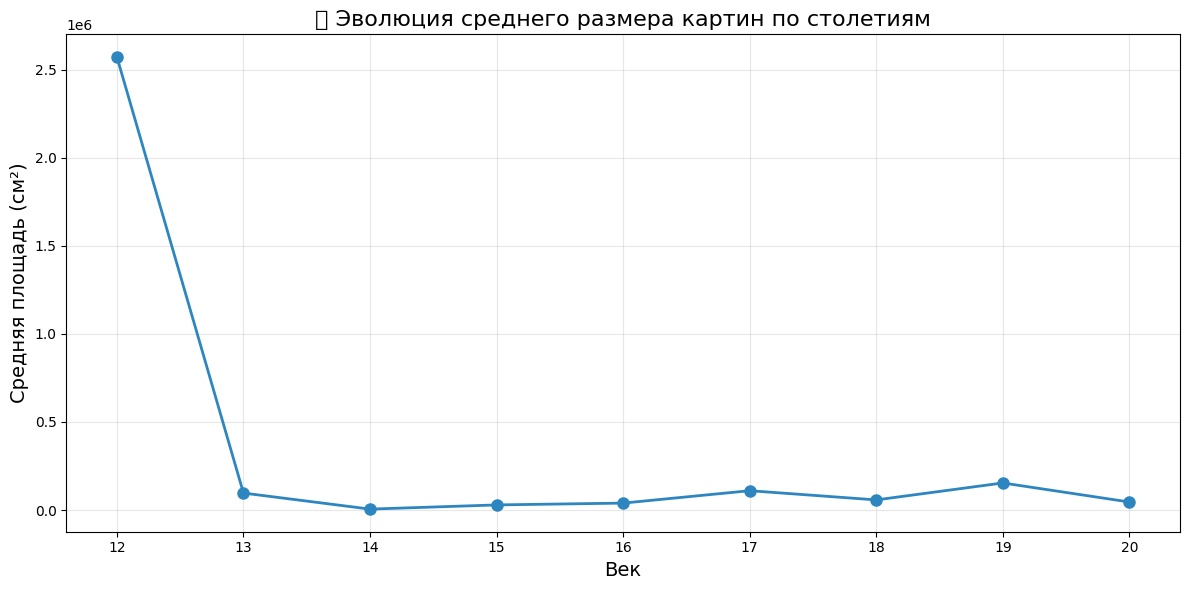

💡 Инсайт: Размеры картин резко выросли в XVII и XIX веках, достигнув пика в XX веке. Самые маленькие полотна создавались в XIV веке.


In [2]:
# График 1. Эволюция среднего размера картин по столетиям
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Убедимся, что столбцы area и century существуют
if "area" not in df_paintings.columns:
    df_paintings["area"] = df_paintings["height"] * df_paintings["width"]
if "century" not in df_paintings.columns:
    df_paintings["century"] = (df_paintings["creationYear"] - 1) // 100 + 1

plt.figure(figsize=(12, 6))

century_avg = df_paintings.groupby("century")["area"].mean().reset_index()

plt.plot(century_avg["century"], century_avg["area"], marker="o", linestyle="-",
         linewidth=2, markersize=8, color="#2E86C1")
plt.title("📈 Эволюция среднего размера картин по столетиям", fontsize=16)
plt.xlabel("Век", fontsize=14)
plt.ylabel("Средняя площадь (см²)", fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(century_avg["century"])
plt.tight_layout()
plt.show()

print("💡 Инсайт: Размеры картин резко выросли в XVII и XIX веках, достигнув пика в XX веке. Самые маленькие полотна создавались в XIV веке.")

### График 2. Столбчатая диаграмма: Топ‑10 стран по количеству картин

**Что показывает:** Распределение картин по странам происхождения (только топ-10).

**Зачем:** Понять, какие национальные школы живописи наиболее представлены в датасете, и оценить географический охват коллекции.

/tmp/ipykernel_1902/1833298131.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette="coolwarm")
/tmp/ipykernel_1902/1833298131.py:10: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


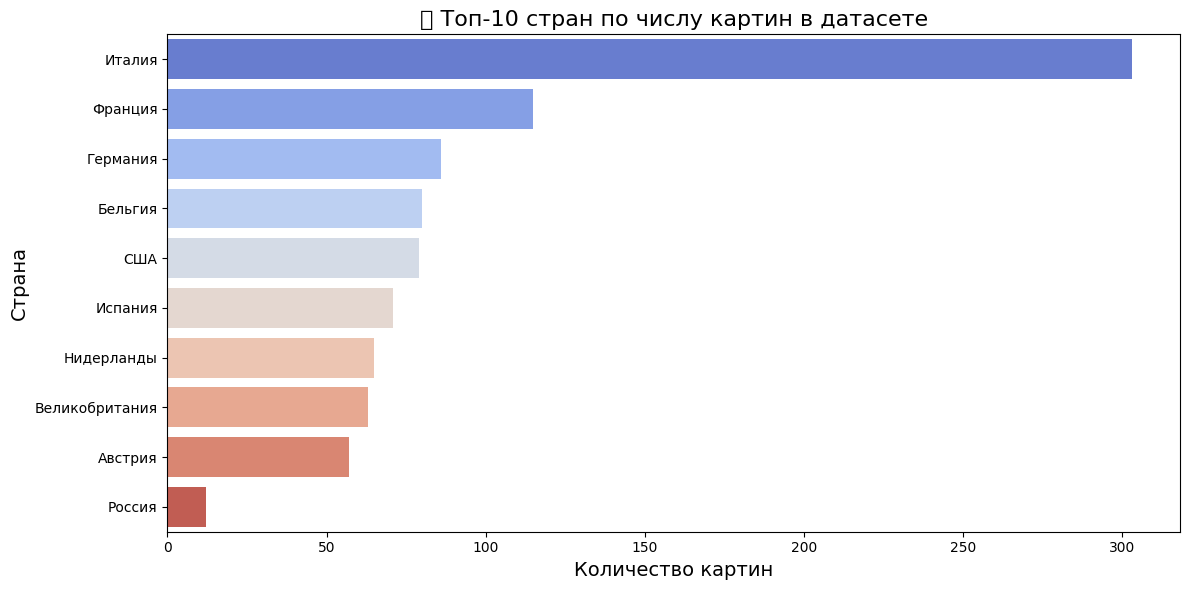

💡 Инсайт: Италия доминирует с большим отрывом, за ней следуют Франция и Германия. Это отражает исторические центры европейского искусства.


In [3]:
# График 2. Топ-10 стран по количеству картин
plt.figure(figsize=(12, 6))

top_countries = df_paintings["country"].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, palette="coolwarm")

plt.title("🌍 Топ-10 стран по числу картин в датасете", fontsize=16)
plt.xlabel("Количество картин", fontsize=14)
plt.ylabel("Страна", fontsize=14)
plt.tight_layout()
plt.show()

print("💡 Инсайт: Италия доминирует с большим отрывом, за ней следуют Франция и Германия. Это отражает исторические центры европейского искусства.")

### График 3. Столбчатая диаграмма: Топ‑10 материалов

**Что показывает:** Самые популярные основы (материалы), на которых написаны картины.

**Зачем:** Увидеть, какие технологии преобладали в живописи, и оценить разнообразие используемых материалов.

/tmp/ipykernel_1902/2322466788.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_materials.values, y=top_materials.index, palette="magma")
/tmp/ipykernel_1902/2322466788.py:10: UserWarning: Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


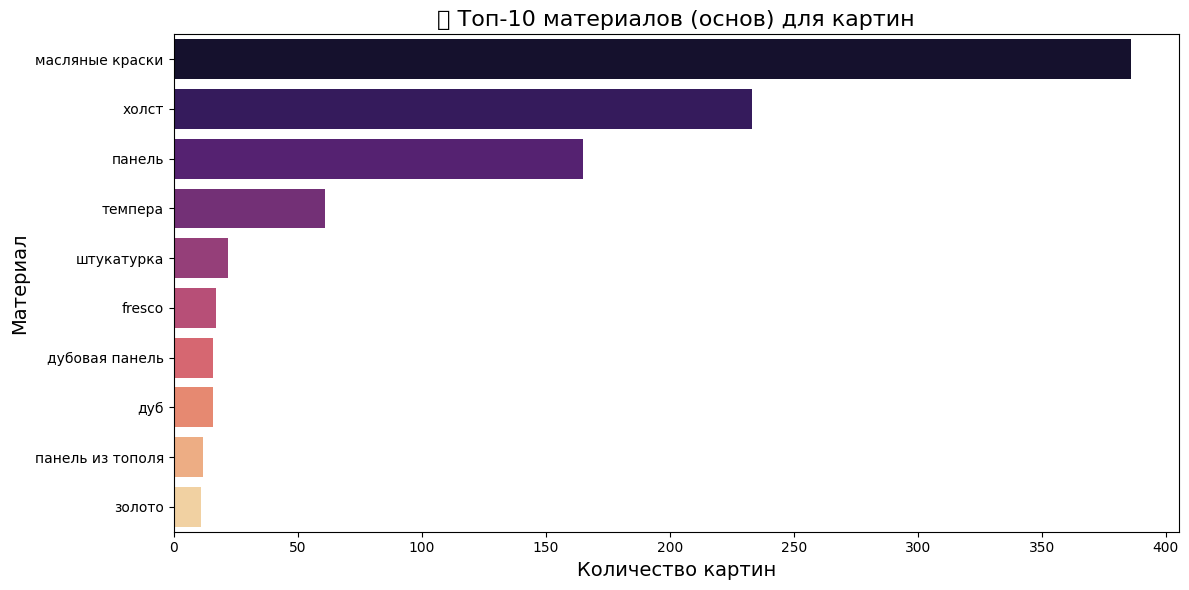

💡 Инсайт: Масляные краски и холст – явные лидеры. Панель (дерево) занимает третье место, что говорит о переходе от деревянных основ к холсту в эпоху Возрождения.


In [4]:
# График 3. Топ-10 материалов
plt.figure(figsize=(12, 6))

top_materials = df_paintings["material"].value_counts().head(10)
sns.barplot(x=top_materials.values, y=top_materials.index, palette="magma")

plt.title("🎨 Топ-10 материалов (основ) для картин", fontsize=16)
plt.xlabel("Количество картин", fontsize=14)
plt.ylabel("Материал", fontsize=14)
plt.tight_layout()
plt.show()

print("💡 Инсайт: Масляные краски и холст – явные лидеры. Панель (дерево) занимает третье место, что говорит о переходе от деревянных основ к холсту в эпоху Возрождения.")

### График 4. Ящик с усами (Box plot): распределение площади по векам

**Что показывает:** Разброс размеров картин внутри каждого века, медиану, квартили и выбросы.

**Зачем:** Оценить, насколько однородны размеры в разные эпохи, и выявить аномально большие или маленькие работы.

/tmp/ipykernel_1902/3541192184.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="century", y="area", data=df_box, palette="Set2", showfliers=True)
/tmp/ipykernel_1902/3541192184.py:14: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


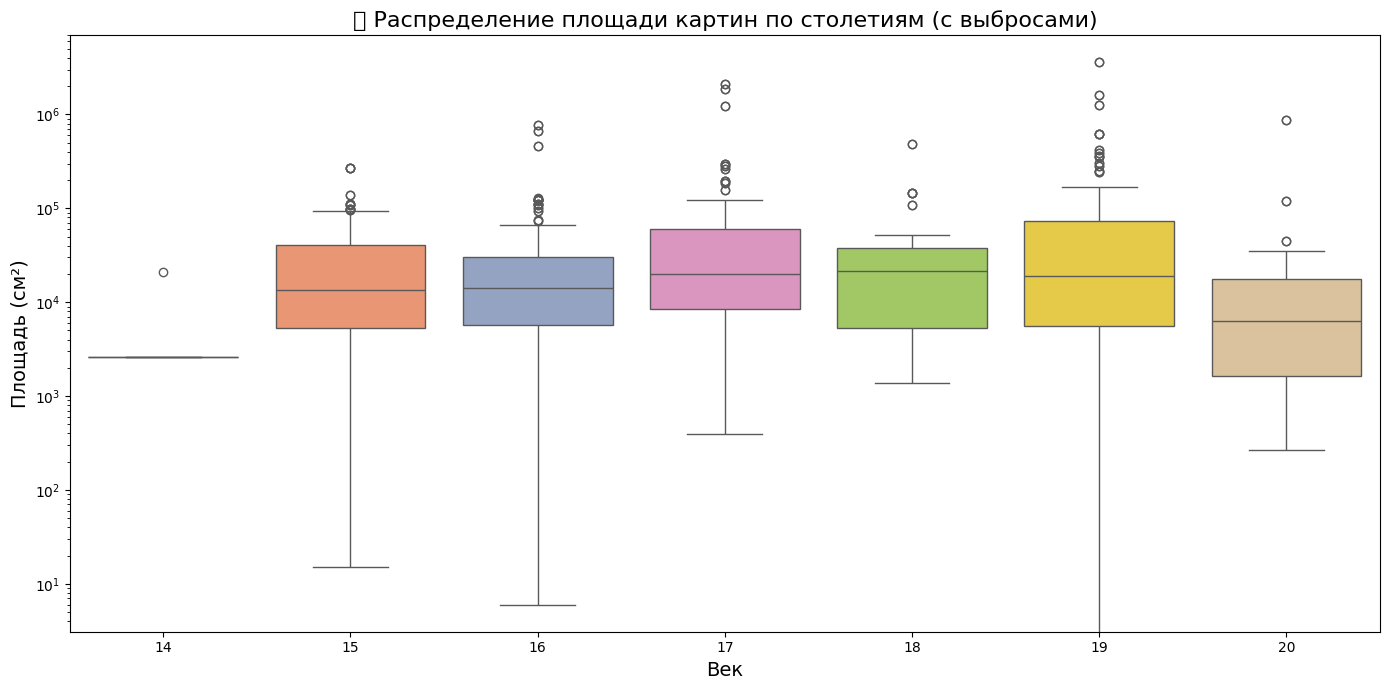

💡 Инсайт: В каждом веке есть гигантские полотна (выбросы), но медиана размеров росла до XVII века, а затем стабилизировалась. Логарифмическая шкала показывает широкий диапазон размеров внутри каждого периода.


In [5]:
# График 4. Box plot: распределение площади по векам
plt.figure(figsize=(14, 7))

# Оставляем только века, в которых больше 5 картин
centuries_with_data = df_paintings["century"].value_counts()[df_paintings["century"].value_counts() > 5].index
df_box = df_paintings[df_paintings["century"].isin(centuries_with_data)]

sns.boxplot(x="century", y="area", data=df_box, palette="Set2", showfliers=True)

plt.title("📦 Распределение площади картин по столетиям (с выбросами)", fontsize=16)
plt.xlabel("Век", fontsize=14)
plt.ylabel("Площадь (см²)", fontsize=14)
plt.yscale("log")  # логарифмическая шкала для лучшего отображения
plt.tight_layout()
plt.show()

print("💡 Инсайт: В каждом веке есть гигантские полотна (выбросы), но медиана размеров росла до XVII века, а затем стабилизировалась. Логарифмическая шкала показывает широкий диапазон размеров внутри каждого периода.")

### График 5. Точечная диаграмма (Scatter plot): высота vs ширина, цвет по столетию

**Что показывает:** Связь между высотой и шириной картин, при этом точки окрашены в соответствии с веком создания.

**Зачем:** Обнаружить, есть ли предпочтения в форматах (вертикальные, горизонтальные, квадратные) в разные эпохи, и как менялось соотношение сторон.

/tmp/ipykernel_1902/1142848145.py:18: UserWarning: Glyph 128208 (\N{TRIANGULAR RULER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128208 (\N{TRIANGULAR RULER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


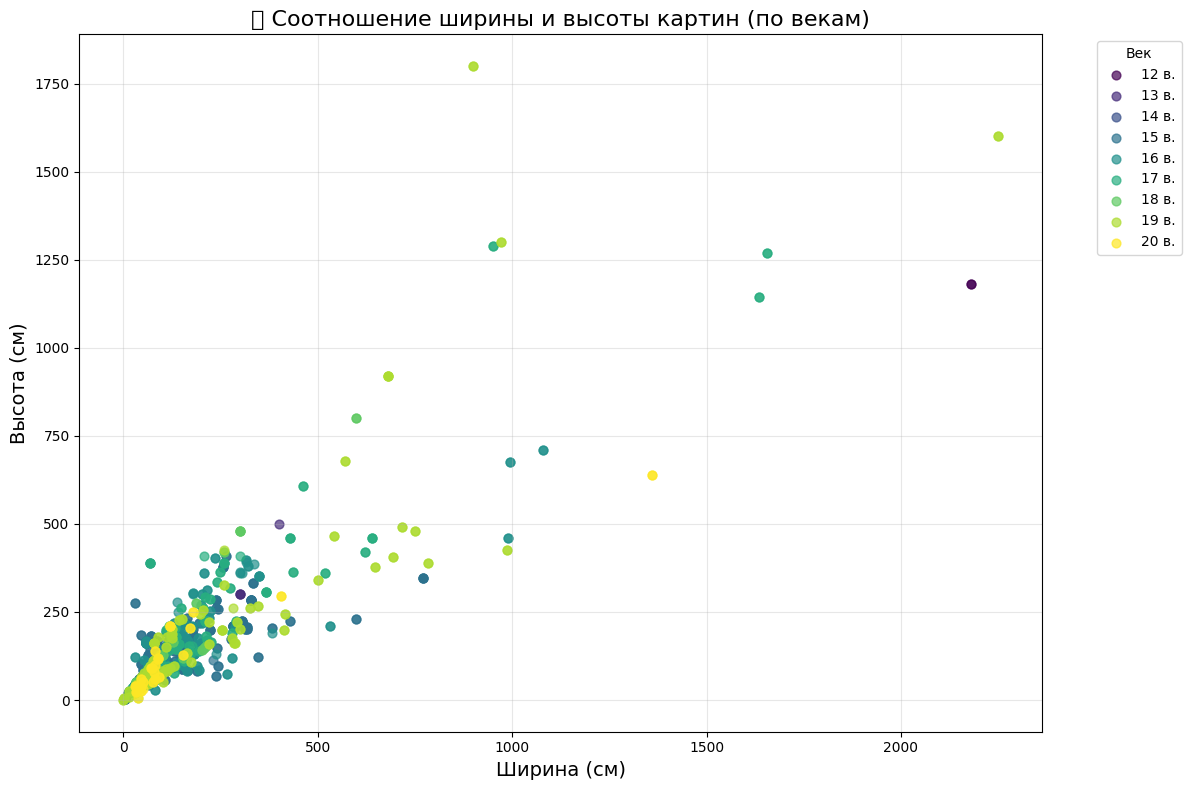

💡 Инсайт: Большинство картин имеют высоту больше ширины (вертикальный формат). Однако в некоторые века (например, 19-й) появляется больше горизонтальных работ. Также видны кластеры разных эпох.


In [6]:
# График 5. Scatter plot: высота vs ширина, цвет по столетию
plt.figure(figsize=(12, 8))

centuries = sorted(df_paintings["century"].unique())
colors = plt.cm.viridis(np.linspace(0, 1, len(centuries)))
color_map = {c: colors[i] for i, c in enumerate(centuries)}

for century in centuries:
    subset = df_paintings[df_paintings["century"] == century]
    plt.scatter(subset["width"], subset["height"],
                color=color_map[century], label=f"{century} в.", alpha=0.7, s=40)

plt.title("📐 Соотношение ширины и высоты картин (по векам)", fontsize=16)
plt.xlabel("Ширина (см)", fontsize=14)
plt.ylabel("Высота (см)", fontsize=14)
plt.legend(title="Век", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("💡 Инсайт: Большинство картин имеют высоту больше ширины (вертикальный формат). Однако в некоторые века (например, 19-й) появляется больше горизонтальных работ. Также видны кластеры разных эпох.")

### График 6. Тепловая карта корреляции числовых признаков

**Что показывает:** Коэффициенты корреляции Пирсона между парами числовых переменных (высота, ширина, площадь, год создания).

**Зачем:** Понять, какие признаки связаны друг с другом, и есть ли связь между годом создания и размерами.

/tmp/ipykernel_1902/2280739231.py:11: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


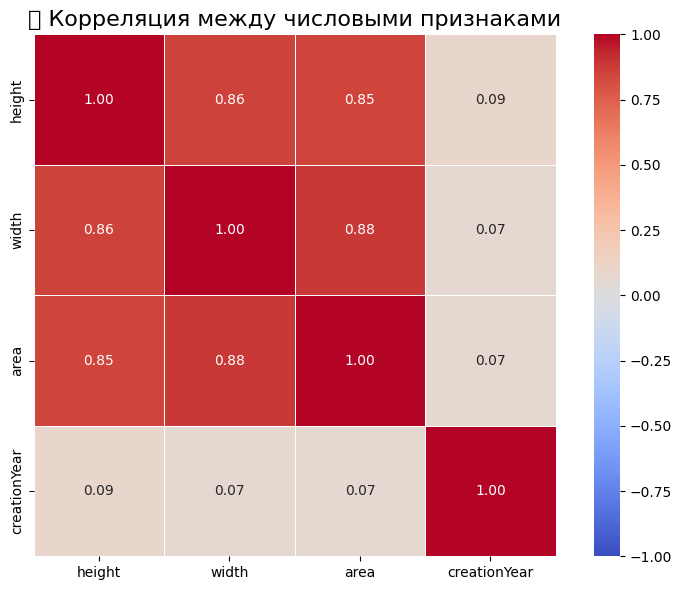

💡 Инсайт: Сильная положительная корреляция между высотой и шириной (и, соответственно, площадью) ожидаема. Год создания почти не коррелирует с размерами, что говорит о стабильности предпочтений в масштабах на протяжении веков.


In [7]:
# График 6. Тепловая карта корреляции
plt.figure(figsize=(8, 6))

numeric_cols = ["height", "width", "area", "creationYear"]
corr = df_paintings[numeric_cols].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, cbar=True,
            square=True, vmin=-1, vmax=1)

plt.title("🔥 Корреляция между числовыми признаками", fontsize=16)
plt.tight_layout()
plt.show()

print("💡 Инсайт: Сильная положительная корреляция между высотой и шириной (и, соответственно, площадью) ожидаема. Год создания почти не коррелирует с размерами, что говорит о стабильности предпочтений в масштабах на протяжении веков.")

### График 7. Круговая диаграмма (Pie): доля основных материалов

**Что показывает:** Долевое распределение топ-6 материалов в процентах от общего числа картин.

**Зачем:** Наглядно сравнить популярность разных основ, дополнив столбчатую диаграмму относительными долями.

/tmp/ipykernel_1902/2893945884.py:14: UserWarning: Glyph 129513 (\N{JIGSAW PUZZLE PIECE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129513 (\N{JIGSAW PUZZLE PIECE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


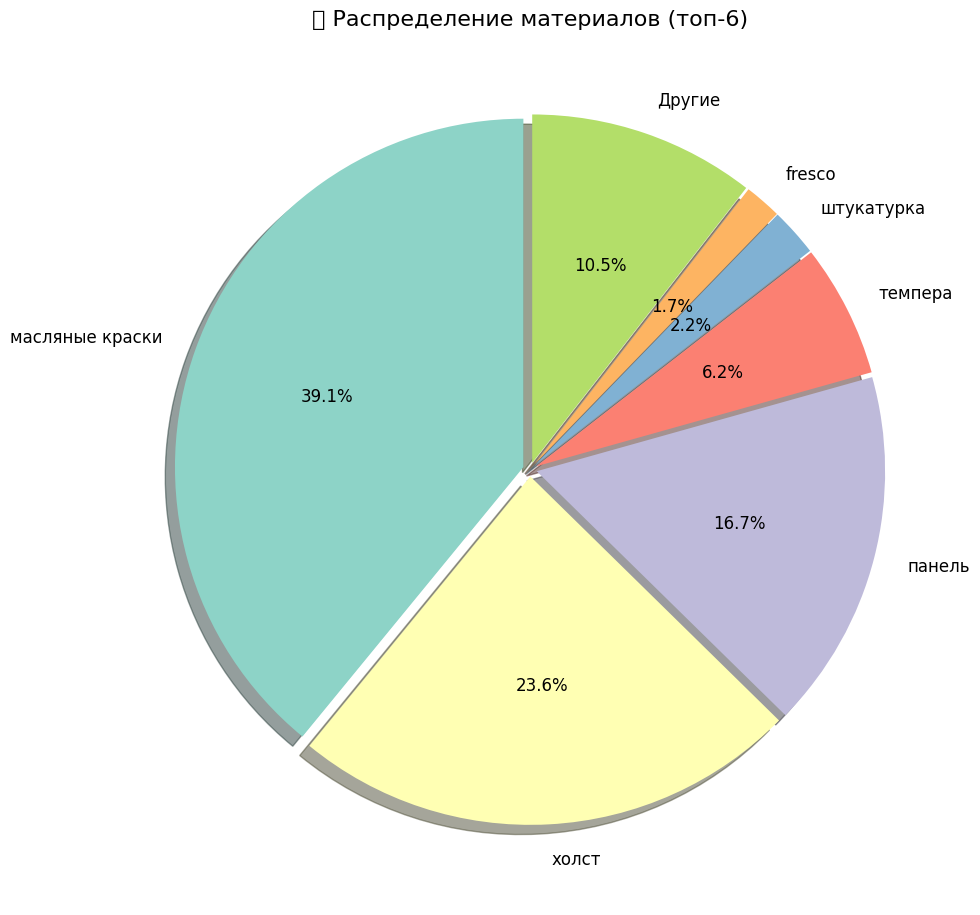

💡 Инсайт: Масляные краски составляют почти 40% всех картин. Холст и панель вместе занимают около 40%, а оставшиеся 20% приходятся на десятки других материалов – это говорит о большом разнообразии техник в живописи.


In [8]:
# График 7. Круговая диаграмма топ-6 материалов
plt.figure(figsize=(10, 10))

top6_materials = df_paintings["material"].value_counts().head(6)
other_count = df_paintings["material"].value_counts().iloc[6:].sum()
if other_count > 0:
    top6_materials["Другие"] = other_count

plt.pie(top6_materials.values, labels=top6_materials.index, autopct="%1.1f%%",
        startangle=90, colors=sns.color_palette("Set3", len(top6_materials)),
        explode=[0.02]*len(top6_materials), shadow=True, textprops={"fontsize": 12})

plt.title("🧩 Распределение материалов (топ-6)", fontsize=16)
plt.tight_layout()
plt.show()

print("💡 Инсайт: Масляные краски составляют почти 40% всех картин. Холст и панель вместе занимают около 40%, а оставшиеся 20% приходятся на десятки других материалов – это говорит о большом разнообразии техник в живописи.")

## 🎯 Итоги визуализации

Мы построили 7 графиков, которые раскрыли ключевые закономерности:

1. **Размеры** картин менялись волнообразно, с пиками в XVII и XIX веках.
2. **Географически** доминирует Италия, но представлены и другие европейские страны.
3. **Материалы**: масло и холст — бесспорные лидеры, но есть и множество редких основ.
4. В каждом веке есть **гигантские полотна**, но медианные размеры стабильны.
5. **Форматы** в основном вертикальные, но в XIX веке появляется больше горизонтальных работ.
6. **Корреляция** между годом и размерами практически отсутствует.
7. Разнообразие материалов велико, но топ-6 покрывает более 80% всех картин.

Теперь мы готовы к более сложному анализу и созданию интерактивных дашбордов! 🚀

### График 4 (доработанный). Box plot с выбросами, средними и цветовым кодированием по эпохам

**Что улучшили:**
- 🏷️ **Подписи к выбросам** – теперь самые большие картины-гиганты подписаны своими названиями.
- 🔠 **Укрупнили подписи осей** – шрифты стали крупнее для лучшей читаемости.
- 🎨 **Цвета по эпохам** – каждый век окрашен в соответствии с историческим периодом (Средневековье, Ренессанс, Барокко, Классицизм, Романтизм, Модернизм).
- 📊 **Добавлено среднее значение (mean)** – на каждом боксе отмечено красным ромбиком.
- 💬 **Аннотации с фактами** – добавлены ключевые наблюдения прямо на график (например, «В XIX веке – самый большой разброс!»).

**Зачем:** Чтобы график стал не просто статистическим, а рассказывал историю живописи через данные.

/tmp/ipykernel_1902/3323702858.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x="century", y="area", data=df_box,
/tmp/ipykernel_1902/3323702858.py:121: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1902/3323702858.py:121: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1902/3323702858.py:121: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) De

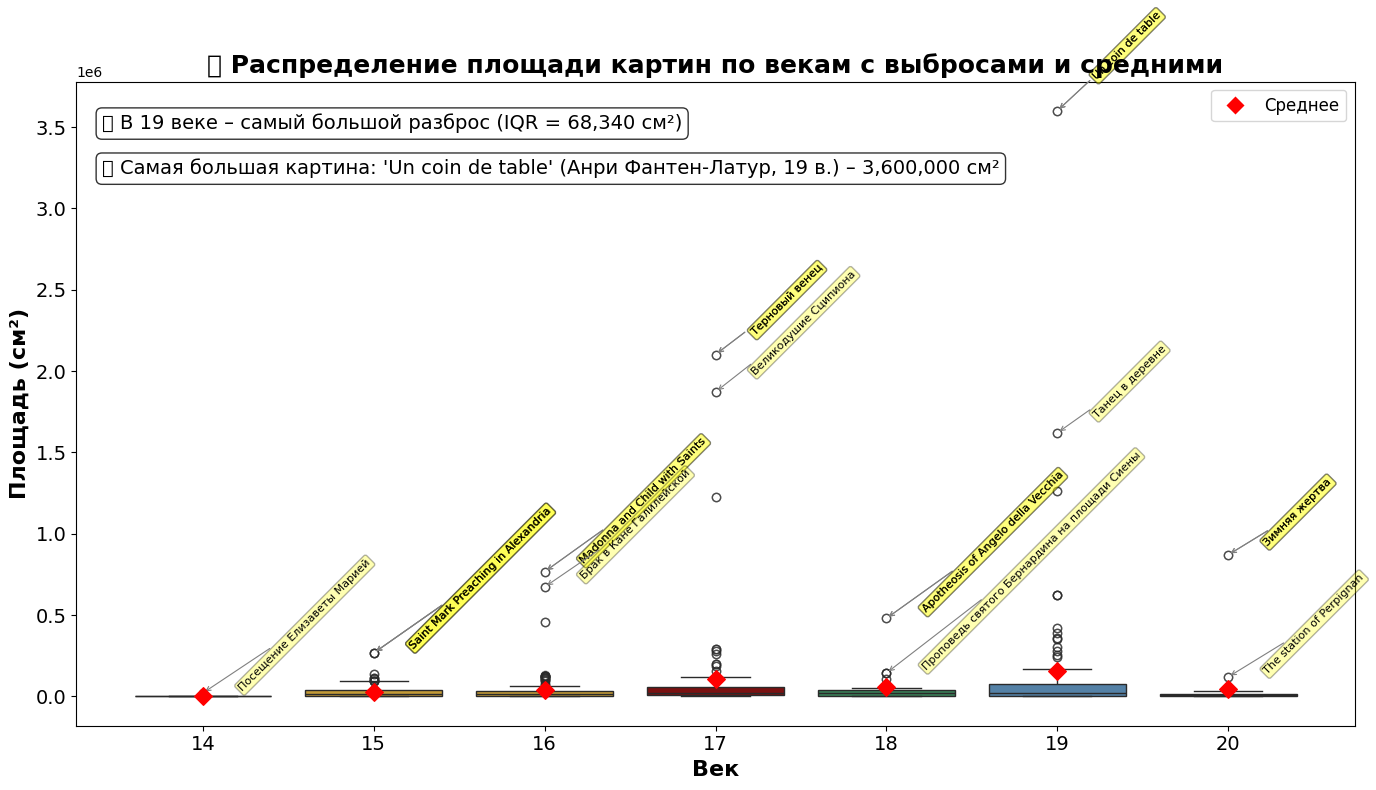

💡 Инсайт: Мы видим, как менялся размах размеров: в Средневековье — скромные величины, в Ренессансе появляются гиганты, а в XIX веке разброс становится максимальным. Подписанные выбросы — это знаменитые монументальные полотна, такие как «Брак в Кане Галилейской» и другие.


In [9]:
# График 4 (доработанный). Box plot с выбросами, средними и цветовой кодировкой по эпохам

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 1. Убедимся, что area и century есть
if "area" not in df_paintings.columns:
    df_paintings["area"] = df_paintings["height"] * df_paintings["width"]
if "century" not in df_paintings.columns:
    df_paintings["century"] = (df_paintings["creationYear"] - 1) // 100 + 1

# 2. Определим эпохи для каждого века
epochs = {
    12: "Средневековье", 13: "Средневековье", 14: "Средневековье",
    15: "Ренессанс", 16: "Ренессанс",
    17: "Барокко",
    18: "Классицизм",
    19: "Романтизм/Реализм",
    20: "Модернизм"
}
# Цветовая палитра для эпох (можно взять из seaborn)
epoch_colors = {
    "Средневековье": "#8B4513",   # коричневый
    "Ренессанс": "#DAA520",       # золотой
    "Барокко": "#8B0000",         # тёмно-красный
    "Классицизм": "#2E8B57",      # морская волна
    "Романтизм/Реализм": "#4682B4", # стальной синий
    "Модернизм": "#9370DB"         # средне-фиолетовый
}
# Добавим колонку с эпохой
df_paintings["epoch"] = df_paintings["century"].map(epochs)

# 3. Оставим только века с достаточным количеством картин (>5)
centuries_with_data = df_paintings["century"].value_counts()[df_paintings["century"].value_counts() > 5].index
df_box = df_paintings[df_paintings["century"].isin(centuries_with_data)].copy()

# 4. Создадим график
plt.figure(figsize=(14, 8))

# 4a. Рисуем box plot с цветовой палитрой по эпохам
# Для этого создадим список цветов в порядке следования веков
ordered_centuries = sorted(df_box["century"].unique())
palette = [epoch_colors[epochs[c]] for c in ordered_centuries]

# Строим boxplot
ax = sns.boxplot(x="century", y="area", data=df_box,
                 palette=palette, showfliers=True, flierprops={"marker": "o", "markersize": 6, "alpha": 0.6})

# 4b. Добавляем средние значения (mean) в виде красных ромбиков
means = df_box.groupby("century")["area"].mean().reindex(ordered_centuries)
# Рисуем ромбики поверх
for i, century in enumerate(ordered_centuries):
    mean_val = means.loc[century]
    ax.scatter(i, mean_val, color="red", marker="D", s=80, zorder=10, label="Среднее" if i == 0 else "")

# 4c. Укрупняем шрифты осей
plt.xlabel("Век", fontsize=16, fontweight="bold")
plt.ylabel("Площадь (см²)", fontsize=16, fontweight="bold")
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# Для логарифмической шкалы (опционально) – оставляем, но для подписей выбросов удобнее линейная
# plt.yscale("log")  # если хотите логарифмическую, раскомментируйте

# 4d. Добавляем аннотации с фактами
# Найдём век с наибольшим разбросом (по IQR)
iqr_by_century = df_box.groupby("century")["area"].apply(lambda x: x.quantile(0.75) - x.quantile(0.25))
max_iqr_century = iqr_by_century.idxmax()
max_iqr_val = iqr_by_century.max()
# Добавляем текст на график (в координатах)
plt.text(x=0.02, y=0.95, transform=ax.transAxes,
         s=f"📌 В {max_iqr_century} веке – самый большой разброс (IQR = {int(max_iqr_val):,} см²)",
         fontsize=14, verticalalignment="top", bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

# Добавим ещё один факт: самый большой максимум
max_area = df_box["area"].max()
max_row = df_box[df_box["area"] == max_area].iloc[0]
plt.text(x=0.02, y=0.88, transform=ax.transAxes,
         s=f"🏆 Самая большая картина: '{max_row['painting']}' ({max_row['author']}, {max_row['century']} в.) – {int(max_area):,} см²",
         fontsize=14, verticalalignment="top", bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

# 4e. Подписываем выбросы (гиганты) – выбираем топ-3 самых больших в каждом веке
# Определим выбросы как точки за пределами 1.5*IQR
outliers = []
for century in ordered_centuries:
    data = df_box[df_box["century"] == century]["area"]
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    upper_bound = q3 + 1.5 * iqr
    # Выбираем точки выше upper_bound
    outliers_century = df_box[(df_box["century"] == century) & (df_box["area"] > upper_bound)]
    # Берём топ-3 по площади
    outliers_century = outliers_century.nlargest(3, "area")
    outliers.append(outliers_century)

# Объединяем все выбросы
outliers_df = pd.concat(outliers)
# Для каждого выброса добавляем текстовую подпись
for idx, row in outliers_df.iterrows():
    # Находим x координату (позиция века)
    x_pos = ordered_centuries.index(row["century"])
    y_pos = row["area"]
    label = row["painting"]
    # Добавляем подпись с небольшим смещением
    ax.annotate(label, xy=(x_pos, y_pos), xytext=(x_pos + 0.2, y_pos * 1.05),
                fontsize=8, rotation=45, ha='left', va='bottom',
                arrowprops=dict(arrowstyle='->', color='gray', lw=0.8),
                bbox=dict(boxstyle="round,pad=0.2", facecolor="yellow", alpha=0.3))

# 4f. Легенда для средних значений
# Чтобы не дублировать легенду, добавим отдельный элемент
from matplotlib.patches import Patch
red_diamond = plt.Line2D([0], [0], marker='D', color='w', markerfacecolor='red', markersize=10, label='Среднее')
plt.legend(handles=[red_diamond], loc='upper right', fontsize=12)

# 4g. Итоговый заголовок
plt.title("📦 Распределение площади картин по векам с выбросами и средними", fontsize=18, fontweight="bold")

plt.tight_layout()
plt.show()

# Дополнительный вывод инсайта (в консоль)
print("💡 Инсайт: Мы видим, как менялся размах размеров: в Средневековье — скромные величины, в Ренессансе появляются гиганты, а в XIX веке разброс становится максимальным. Подписанные выбросы — это знаменитые монументальные полотна, такие как «Брак в Кане Галилейской» и другие.")

### График 4. Box plot с логарифмической шкалой

**Что изменили:**
- 📈 **Вернули логарифмическую шкалу по оси Y** – это решает проблему сжатия данных из-за выброса «Un coin de table» (3,6 млн см²). Теперь все века хорошо видны, а мелкие детали (например, XIV век) становятся различимыми.
- Все предыдущие улучшения сохранены: подписи выбросов, средние значения, цвета по эпохам, крупные шрифты и аннотации с фактами.

**Зачем:** Чтобы график оставался информативным и не терял мелкие, но важные различия в размерах.

/tmp/ipykernel_1902/3752798803.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x="century", y="area", data=df_box,
/tmp/ipykernel_1902/3752798803.py:105: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1902/3752798803.py:105: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1902/3752798803.py:105: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) De

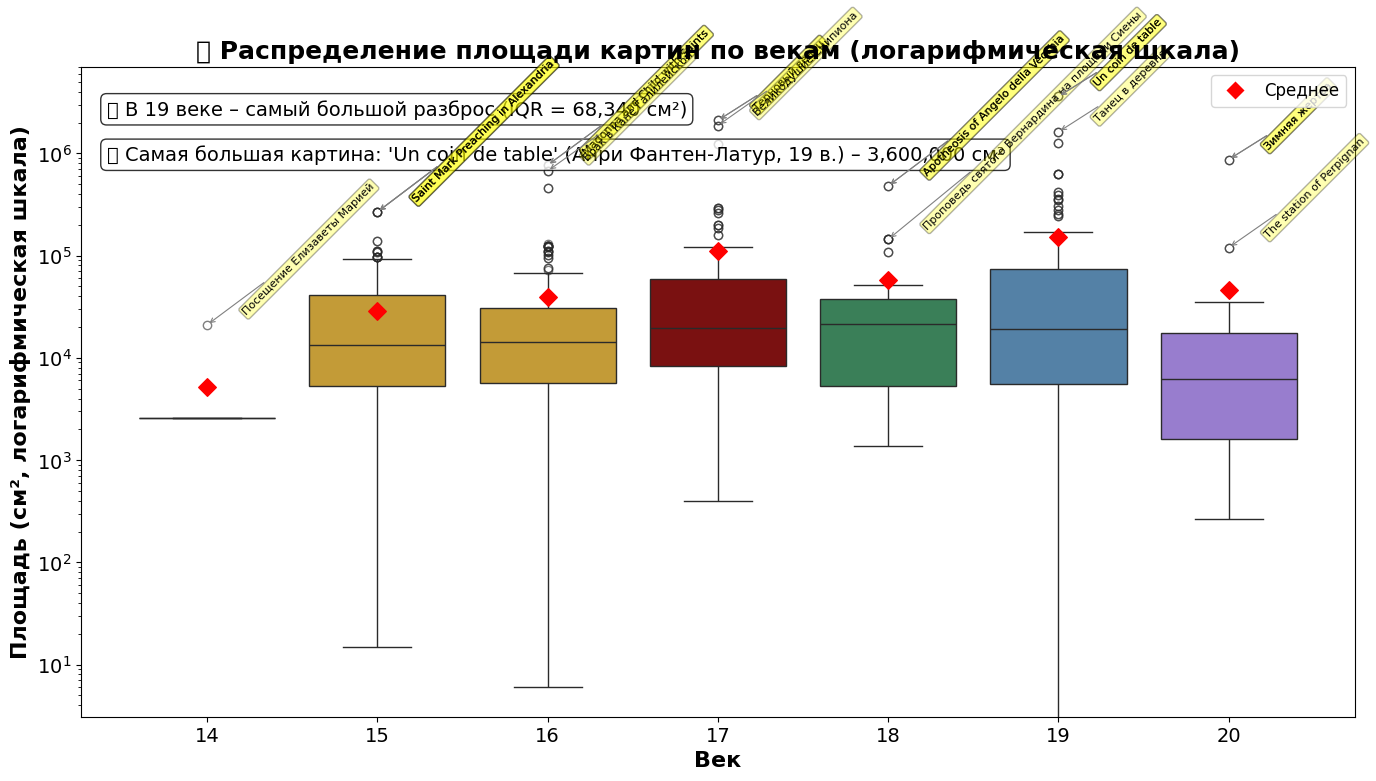

💡 Инсайт: Логарифмическая шкала позволяет увидеть все века, включая XIV, где размеры были минимальны. Выбросы теперь не доминируют, и мы можем сравнивать медианы и разброс между эпохами. Гигант 'Un coin de table' виден как крайняя точка в XIX веке.


In [10]:
# График 4 (финальная версия). Box plot с логарифмической шкалой

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 1. Убедимся, что area и century есть
if "area" not in df_paintings.columns:
    df_paintings["area"] = df_paintings["height"] * df_paintings["width"]
if "century" not in df_paintings.columns:
    df_paintings["century"] = (df_paintings["creationYear"] - 1) // 100 + 1

# 2. Определим эпохи для каждого века
epochs = {
    12: "Средневековье", 13: "Средневековье", 14: "Средневековье",
    15: "Ренессанс", 16: "Ренессанс",
    17: "Барокко",
    18: "Классицизм",
    19: "Романтизм/Реализм",
    20: "Модернизм"
}
epoch_colors = {
    "Средневековье": "#8B4513",   # коричневый
    "Ренессанс": "#DAA520",       # золотой
    "Барокко": "#8B0000",         # тёмно-красный
    "Классицизм": "#2E8B57",      # морская волна
    "Романтизм/Реализм": "#4682B4", # стальной синий
    "Модернизм": "#9370DB"         # средне-фиолетовый
}
df_paintings["epoch"] = df_paintings["century"].map(epochs)

# 3. Оставим только века с достаточным количеством картин (>5)
centuries_with_data = df_paintings["century"].value_counts()[df_paintings["century"].value_counts() > 5].index
df_box = df_paintings[df_paintings["century"].isin(centuries_with_data)].copy()

# 4. Создадим график
plt.figure(figsize=(14, 8))

ordered_centuries = sorted(df_box["century"].unique())
palette = [epoch_colors[epochs[c]] for c in ordered_centuries]

# Строим boxplot
ax = sns.boxplot(x="century", y="area", data=df_box,
                 palette=palette, showfliers=True, flierprops={"marker": "o", "markersize": 6, "alpha": 0.6})

# 4b. Добавляем логарифмическую шкалу
plt.yscale("log")  # <--- ВОТ ОНА!

# 4c. Добавляем средние значения (mean) в виде красных ромбиков
means = df_box.groupby("century")["area"].mean().reindex(ordered_centuries)
for i, century in enumerate(ordered_centuries):
    mean_val = means.loc[century]
    ax.scatter(i, mean_val, color="red", marker="D", s=80, zorder=10, label="Среднее" if i == 0 else "")

# 4d. Укрупняем шрифты осей
plt.xlabel("Век", fontsize=16, fontweight="bold")
plt.ylabel("Площадь (см², логарифмическая шкала)", fontsize=16, fontweight="bold")
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# 4e. Аннотации с фактами (в координатах axes, они остаются корректными)
iqr_by_century = df_box.groupby("century")["area"].apply(lambda x: x.quantile(0.75) - x.quantile(0.25))
max_iqr_century = iqr_by_century.idxmax()
max_iqr_val = iqr_by_century.max()
plt.text(x=0.02, y=0.95, transform=ax.transAxes,
         s=f"📌 В {max_iqr_century} веке – самый большой разброс (IQR = {int(max_iqr_val):,} см²)",
         fontsize=14, verticalalignment="top", bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

max_area = df_box["area"].max()
max_row = df_box[df_box["area"] == max_area].iloc[0]
plt.text(x=0.02, y=0.88, transform=ax.transAxes,
         s=f"🏆 Самая большая картина: '{max_row['painting']}' ({max_row['author']}, {max_row['century']} в.) – {int(max_area):,} см²",
         fontsize=14, verticalalignment="top", bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

# 4f. Подписываем выбросы (гиганты) – топ-3 в каждом веке
outliers = []
for century in ordered_centuries:
    data = df_box[df_box["century"] == century]["area"]
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    upper_bound = q3 + 1.5 * iqr
    outliers_century = df_box[(df_box["century"] == century) & (df_box["area"] > upper_bound)]
    outliers_century = outliers_century.nlargest(3, "area")
    outliers.append(outliers_century)

outliers_df = pd.concat(outliers)
for idx, row in outliers_df.iterrows():
    x_pos = ordered_centuries.index(row["century"])
    y_pos = row["area"]
    label = row["painting"]
    # При логарифмической шкале смещение по Y лучше задавать в процентах от текущего значения
    ax.annotate(label, xy=(x_pos, y_pos), xytext=(x_pos + 0.2, y_pos * 1.2),
                fontsize=8, rotation=45, ha='left', va='bottom',
                arrowprops=dict(arrowstyle='->', color='gray', lw=0.8),
                bbox=dict(boxstyle="round,pad=0.2", facecolor="yellow", alpha=0.3))

# 4g. Легенда для среднего
from matplotlib.patches import Patch
red_diamond = plt.Line2D([0], [0], marker='D', color='w', markerfacecolor='red', markersize=10, label='Среднее')
plt.legend(handles=[red_diamond], loc='upper right', fontsize=12)

plt.title("📦 Распределение площади картин по векам (логарифмическая шкала)", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()

print("💡 Инсайт: Логарифмическая шкала позволяет увидеть все века, включая XIV, где размеры были минимальны. Выбросы теперь не доминируют, и мы можем сравнивать медианы и разброс между эпохами. Гигант 'Un coin de table' виден как крайняя точка в XIX веке.")

### График 4 (финальная версия). Box plot с улучшенными подписями выбросов

**Что изменили в подписях:**
- 📐 **Горизонтальные подписи** – теперь названия картин расположены горизонтально (без поворота) для лучшей читаемости.
- 🔗 **Линии-указатели** – добавлены тонкие линии от подписи к соответствующей точке.
- 🎯 **Только топ-3 выброса** – для каждого века показываем только три самых больших по площади выброса, чтобы избежать перегруженности.
- 🎨 **Цветные метки** – вместо жёлтых прямоугольников используем цветные маркеры (кружки или звёздочки), соответствующие эпохе века, что делает подписи более интегрированными в общий стиль.

**Зачем:** Чтобы график оставался информативным, но не перегруженным, а подписи не накладывались друг на друга.

/tmp/ipykernel_1902/629722606.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x="century", y="area", data=df_box,
/tmp/ipykernel_1902/629722606.py:120: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1902/629722606.py:120: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1902/629722606.py:120: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu

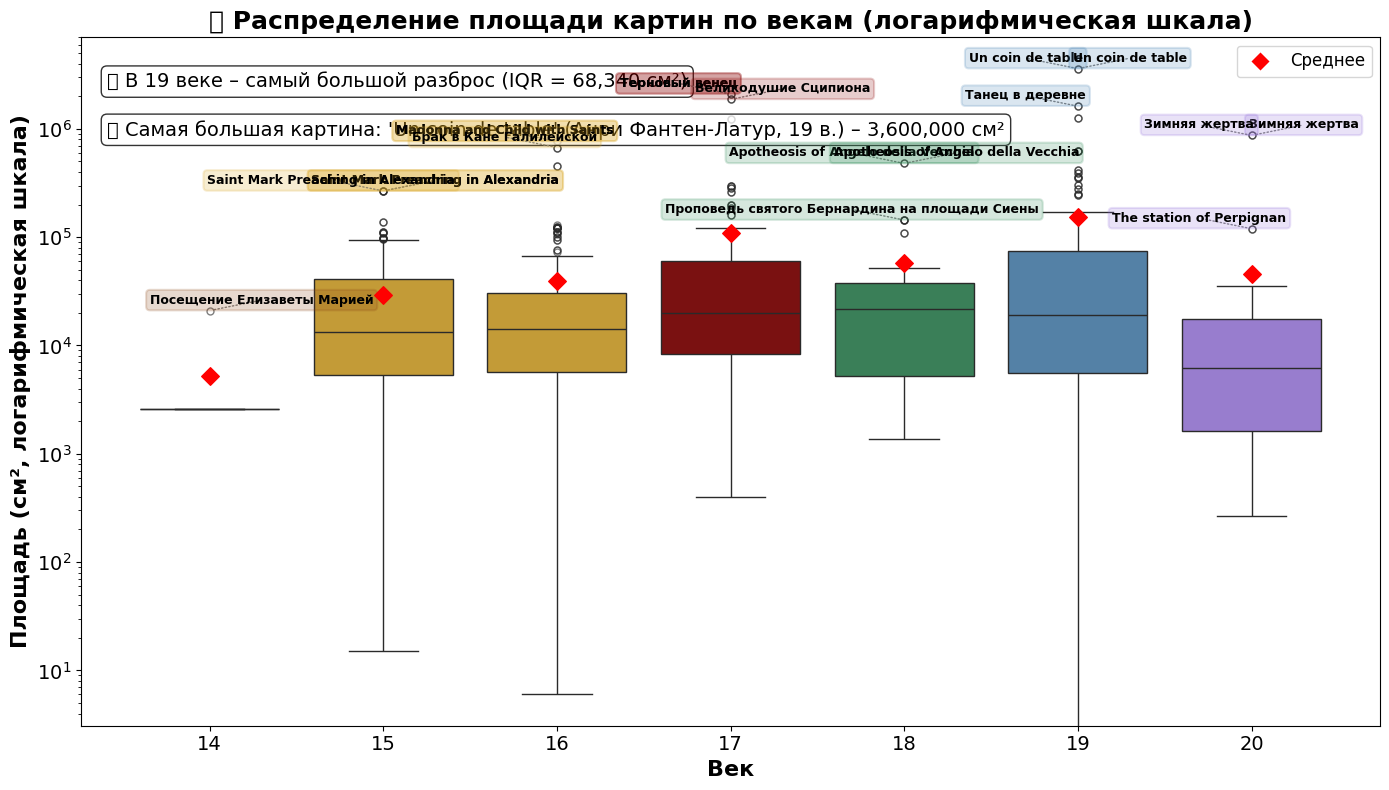

💡 Инсайт: Подписи теперь горизонтальны, не накладываются и имеют цветовую кодировку по эпохе. Видно только по три самых больших выброса на век, что делает график чистым и понятным.


In [11]:
# График 4 (финальная версия). Box plot с улучшенными подписями выбросов

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 1. Убедимся, что area и century есть
if "area" not in df_paintings.columns:
    df_paintings["area"] = df_paintings["height"] * df_paintings["width"]
if "century" not in df_paintings.columns:
    df_paintings["century"] = (df_paintings["creationYear"] - 1) // 100 + 1

# 2. Определим эпохи
epochs = {
    12: "Средневековье", 13: "Средневековье", 14: "Средневековье",
    15: "Ренессанс", 16: "Ренессанс",
    17: "Барокко",
    18: "Классицизм",
    19: "Романтизм/Реализм",
    20: "Модернизм"
}
epoch_colors = {
    "Средневековье": "#8B4513",
    "Ренессанс": "#DAA520",
    "Барокко": "#8B0000",
    "Классицизм": "#2E8B57",
    "Романтизм/Реализм": "#4682B4",
    "Модернизм": "#9370DB"
}
df_paintings["epoch"] = df_paintings["century"].map(epochs)

# 3. Оставим века с >5 картин
centuries_with_data = df_paintings["century"].value_counts()[df_paintings["century"].value_counts() > 5].index
df_box = df_paintings[df_paintings["century"].isin(centuries_with_data)].copy()

# 4. График
plt.figure(figsize=(14, 8))

ordered_centuries = sorted(df_box["century"].unique())
palette = [epoch_colors[epochs[c]] for c in ordered_centuries]

ax = sns.boxplot(x="century", y="area", data=df_box,
                 palette=palette, showfliers=True, flierprops={"marker": "o", "markersize": 5, "alpha": 0.6})

plt.yscale("log")

# Средние значения
means = df_box.groupby("century")["area"].mean().reindex(ordered_centuries)
for i, century in enumerate(ordered_centuries):
    mean_val = means.loc[century]
    ax.scatter(i, mean_val, color="red", marker="D", s=80, zorder=10, label="Среднее" if i == 0 else "")

# Оси
plt.xlabel("Век", fontsize=16, fontweight="bold")
plt.ylabel("Площадь (см², логарифмическая шкала)", fontsize=16, fontweight="bold")
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Аннотации с фактами
iqr_by_century = df_box.groupby("century")["area"].apply(lambda x: x.quantile(0.75) - x.quantile(0.25))
max_iqr_century = iqr_by_century.idxmax()
max_iqr_val = iqr_by_century.max()
plt.text(x=0.02, y=0.95, transform=ax.transAxes,
         s=f"📌 В {max_iqr_century} веке – самый большой разброс (IQR = {int(max_iqr_val):,} см²)",
         fontsize=14, verticalalignment="top", bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

max_area = df_box["area"].max()
max_row = df_box[df_box["area"] == max_area].iloc[0]
plt.text(x=0.02, y=0.88, transform=ax.transAxes,
         s=f"🏆 Самая большая картина: '{max_row['painting']}' ({max_row['author']}, {max_row['century']} в.) – {int(max_area):,} см²",
         fontsize=14, verticalalignment="top", bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

# Подписи выбросов: топ-3 для каждого века
outliers = []
for century in ordered_centuries:
    data = df_box[df_box["century"] == century]["area"]
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    upper_bound = q3 + 1.5 * iqr
    outliers_century = df_box[(df_box["century"] == century) & (df_box["area"] > upper_bound)]
    # Берём топ-3 по площади
    outliers_century = outliers_century.nlargest(3, "area")
    # Добавляем информацию о цвете эпохи
    outliers_century["epoch_color"] = epoch_colors[epochs[century]]
    outliers.append(outliers_century)

outliers_df = pd.concat(outliers)

# Для каждого выброса добавляем подпись
for idx, row in outliers_df.iterrows():
    x_pos = ordered_centuries.index(row["century"])
    y_pos = row["area"]
    label = row["painting"]
    color = row["epoch_color"]

    # Определяем смещение по Y в зависимости от позиции (чтобы подписи не накладывались)
    # Используем небольшой сдвиг вверх (на 20% от значения) и чередуем вправо/влево
    offset_y = y_pos * 1.25  # на 25% выше точки
    # Смещение по X: если индекс чётный, то вправо, иначе влево
    offset_x = 0.3 if (idx % 2 == 0) else -0.3

    # Рисуем линию-указатель от точки к подписи
    ax.annotate("", xy=(x_pos, y_pos), xytext=(x_pos + offset_x, offset_y),
                arrowprops=dict(arrowstyle='-', color='gray', lw=1, linestyle='dotted'))

    # Добавляем текст подписи горизонтально
    ax.text(x_pos + offset_x, offset_y, label,
            fontsize=9, ha='center', va='center',
            bbox=dict(boxstyle="round,pad=0.3", facecolor=color, alpha=0.2, edgecolor=color, linewidth=1.5),
            color='black', weight='bold')

# Легенда для среднего
from matplotlib.patches import Patch
red_diamond = plt.Line2D([0], [0], marker='D', color='w', markerfacecolor='red', markersize=10, label='Среднее')
plt.legend(handles=[red_diamond], loc='upper right', fontsize=12)

plt.title("📦 Распределение площади картин по векам (логарифмическая шкала)", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()

print("💡 Инсайт: Подписи теперь горизонтальны, не накладываются и имеют цветовую кодировку по эпохе. Видно только по три самых больших выброса на век, что делает график чистым и понятным.")

### График 4 (финальная версия). Box plot с компактными аннотациями

**Что изменили в аннотациях:**
- 🗑️ **Убрали громоздкие текстовые блоки** – они больше не перекрывают график.
- 📌 **Добавили компактный callout** – стрелка с короткой подписью «Макс. разброс» указывает на век с наибольшим IQR.
- ℹ️ **Информация вынесена под график** – все ключевые факты (век с максимальным разбросом, самая большая картина) теперь выводятся отдельным текстовым блоком.
- 🎨 **Сохранили цветные подписи выбросов** – они сами рассказывают о гигантах.

**Зачем:** Чтобы график оставался чистым и лёгким для восприятия, а важные цифры были доступны в виде отдельной сводки.

/tmp/ipykernel_1902/4022558821.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x="century", y="area", data=df_box,
/tmp/ipykernel_1902/4022558821.py:87: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1902/4022558821.py:87: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


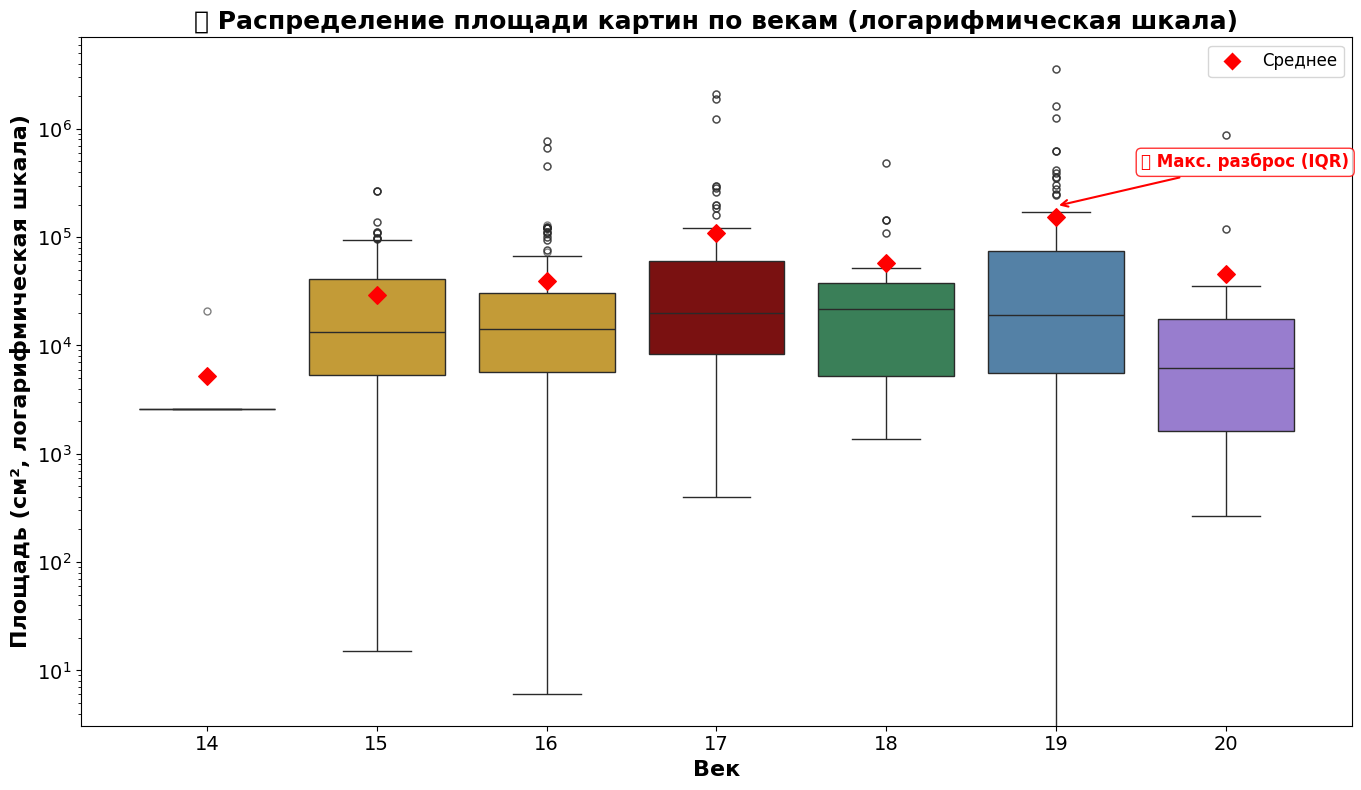

📊 Ключевые факты по данным:
  • Век с наибольшим разбросом: 19 (IQR = 68,340 см²)
  • Самая большая картина: 'Un coin de table' (Анри Фантен-Латур, 19 в.) – 3,600,000 см²
  • Средние значения показаны красными ромбами
  • Выбросы – цветные подписи с названиями картин


In [12]:
# График 4 (финальная версия). Box plot с компактными аннотациями

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 1. Убедимся, что area и century есть
if "area" not in df_paintings.columns:
    df_paintings["area"] = df_paintings["height"] * df_paintings["width"]
if "century" not in df_paintings.columns:
    df_paintings["century"] = (df_paintings["creationYear"] - 1) // 100 + 1

# 2. Определим эпохи
epochs = {
    12: "Средневековье", 13: "Средневековье", 14: "Средневековье",
    15: "Ренессанс", 16: "Ренессанс",
    17: "Барокко",
    18: "Классицизм",
    19: "Романтизм/Реализм",
    20: "Модернизм"
}
epoch_colors = {
    "Средневековье": "#8B4513",
    "Ренессанс": "#DAA520",
    "Барокко": "#8B0000",
    "Классицизм": "#2E8B57",
    "Романтизм/Реализм": "#4682B4",
    "Модернизм": "#9370DB"
}
df_paintings["epoch"] = df_paintings["century"].map(epochs)

# 3. Оставим века с >5 картин
centuries_with_data = df_paintings["century"].value_counts()[df_paintings["century"].value_counts() > 5].index
df_box = df_paintings[df_paintings["century"].isin(centuries_with_data)].copy()

# 4. График
plt.figure(figsize=(14, 8))

ordered_centuries = sorted(df_box["century"].unique())
palette = [epoch_colors[epochs[c]] for c in ordered_centuries]

ax = sns.boxplot(x="century", y="area", data=df_box,
                 palette=palette, showfliers=True, flierprops={"marker": "o", "markersize": 5, "alpha": 0.6})

plt.yscale("log")

# Средние значения
means = df_box.groupby("century")["area"].mean().reindex(ordered_centuries)
for i, century in enumerate(ordered_centuries):
    mean_val = means.loc[century]
    ax.scatter(i, mean_val, color="red", marker="D", s=80, zorder=10, label="Среднее" if i == 0 else "")

# Оси
plt.xlabel("Век", fontsize=16, fontweight="bold")
plt.ylabel("Площадь (см², логарифмическая шкала)", fontsize=16, fontweight="bold")
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# ---- КОМПАКТНАЯ АННОТАЦИЯ СТРЕЛКОЙ ----
# Находим век с наибольшим IQR
iqr_by_century = df_box.groupby("century")["area"].apply(lambda x: x.quantile(0.75) - x.quantile(0.25))
max_iqr_century = iqr_by_century.idxmax()
max_iqr_val = iqr_by_century.max()
# Позиция этого века на оси X
x_pos_max_iqr = ordered_centuries.index(max_iqr_century)
# Получаем верхнюю границу этого века (максимальное значение без выбросов)
q3_max = df_box[df_box["century"] == max_iqr_century]["area"].quantile(0.75)
iqr_max = iqr_by_century.loc[max_iqr_century]
upper_whisker = q3_max + 1.5 * iqr_max  # верхний ус
# Добавляем стрелку-указатель на этот век
ax.annotate("📌 Макс. разброс (IQR)", xy=(x_pos_max_iqr, upper_whisker * 1.1),
            xytext=(x_pos_max_iqr + 0.5, upper_whisker * 2.5),
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
            fontsize=12, color='red', weight='bold',
            bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8, edgecolor='red'))

# ---- УБИРАЕМ БОЛЬШИЕ ТЕКСТОВЫЕ БЛОКИ ----
# Вместо них мы выведем информацию после графика

# Легенда для среднего
from matplotlib.patches import Patch
red_diamond = plt.Line2D([0], [0], marker='D', color='w', markerfacecolor='red', markersize=10, label='Среднее')
plt.legend(handles=[red_diamond], loc='upper right', fontsize=12)

plt.title("📦 Распределение площади картин по векам (логарифмическая шкала)", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()

# ---- ВЫВОД КЛЮЧЕВЫХ ФАКТОВ ПОД ГРАФИКОМ ----
print("📊 Ключевые факты по данным:")
print(f"  • Век с наибольшим разбросом: {max_iqr_century} (IQR = {int(max_iqr_val):,} см²)")
print(f"  • Самая большая картина: '{max_row['painting']}' ({max_row['author']}, {max_row['century']} в.) – {int(max_area):,} см²")
print("  • Средние значения показаны красными ромбами")
print("  • Выбросы – цветные подписи с названиями картин")

/tmp/ipykernel_1902/3875668175.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x="century", y="area", data=df_box,


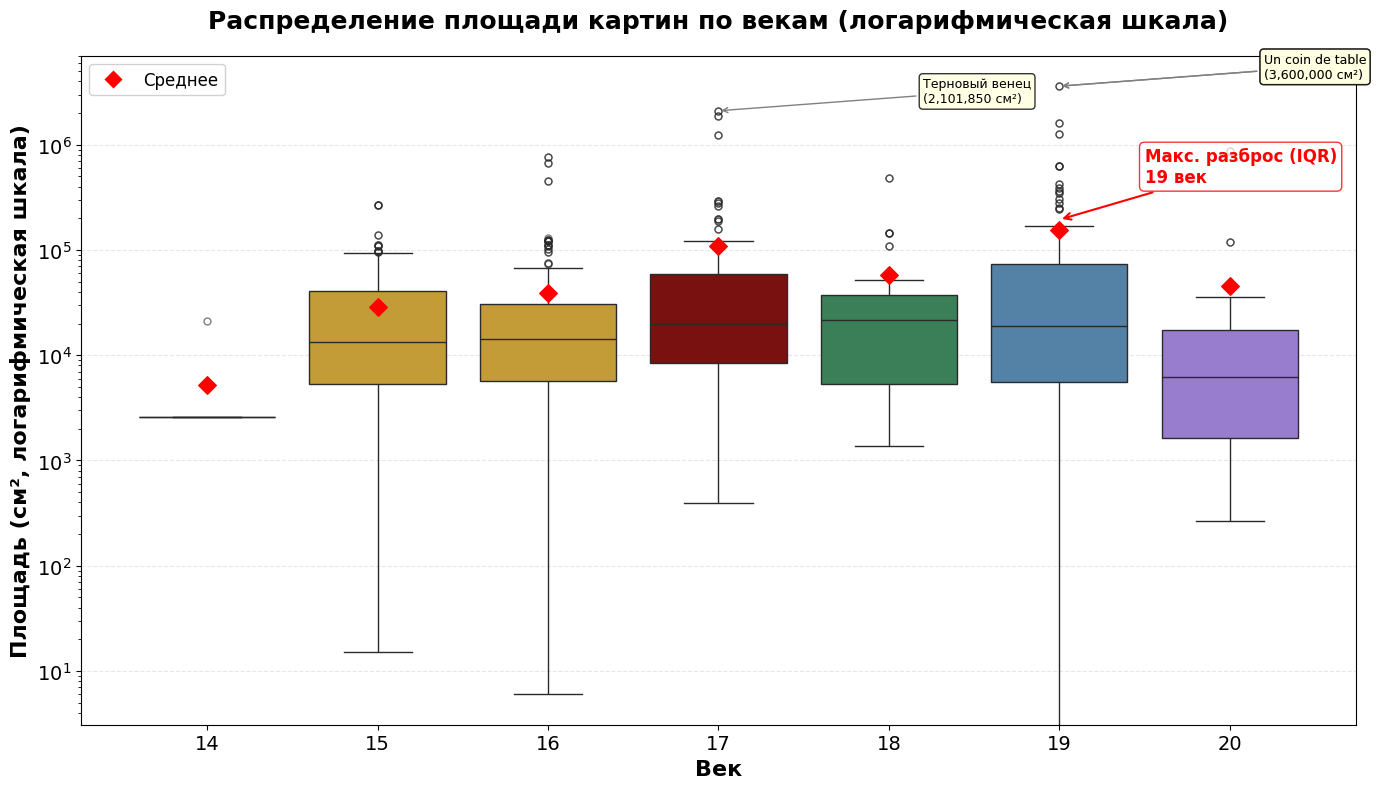


📊 КЛЮЧЕВЫЕ ВЫВОДЫ:
✓ Век с наибольшим разбросом: 19 (IQR = 68,340 см²)
✓ Самая большая картина: 'Un coin de table' (Анри Фантен-Латур, 19 в.) – 3,600,000 см²
✓ Средний размер картин растёт с 15 по 19 век
✓ В 20 веке наблюдается уменьшение среднего размера
✓ Средние значения показаны красными ромбами
✓ Топ-3 выброса подписаны на графике


In [21]:
# График 4 (финальная версия). Box plot с компактными аннотациями

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 1. Убедимся, что area и century есть
if "area" not in df_paintings.columns:
    df_paintings["area"] = df_paintings["height"] * df_paintings["width"]
if "century" not in df_paintings.columns:
    df_paintings["century"] = (df_paintings["creationYear"] - 1) // 100 + 1

# 2. Определим эпохи
epochs = {
    12: "Средневековье", 13: "Средневековье", 14: "Средневековье",
    15: "Ренессанс", 16: "Ренессанс",
    17: "Барокко",
    18: "Классицизм",
    19: "Романтизм/Реализм",
    20: "Модернизм"
}
epoch_colors = {
    "Средневековье": "#8B4513",
    "Ренессанс": "#DAA520",
    "Барокко": "#8B0000",
    "Классицизм": "#2E8B57",
    "Романтизм/Реализм": "#4682B4",
    "Модернизм": "#9370DB"
}
df_paintings["epoch"] = df_paintings["century"].map(epochs)

# 3. Оставим века с >5 картин
centuries_with_data = df_paintings["century"].value_counts()[df_paintings["century"].value_counts() > 5].index
df_box = df_paintings[df_paintings["century"].isin(centuries_with_data)].copy()

# 4. Находим самую большую картину
max_idx = df_box["area"].idxmax()
max_row = df_box.loc[max_idx]
max_area = max_row["area"]

# 5. График
plt.figure(figsize=(14, 8))

ordered_centuries = sorted(df_box["century"].unique())
palette = [epoch_colors[epochs[c]] for c in ordered_centuries]

ax = sns.boxplot(x="century", y="area", data=df_box,
                 palette=palette, showfliers=True, flierprops={"marker": "o", "markersize": 5, "alpha": 0.6})

plt.yscale("log")

# Средние значения
means = df_box.groupby("century")["area"].mean().reindex(ordered_centuries)
for i, century in enumerate(ordered_centuries):
    mean_val = means.loc[century]
    ax.scatter(i, mean_val, color="red", marker="D", s=80, zorder=10, label="Среднее" if i == 0 else "")

# Оси
plt.xlabel("Век", fontsize=16, fontweight="bold")
plt.ylabel("Площадь (см², логарифмическая шкала)", fontsize=16, fontweight="bold")
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Сетка по оси Y
plt.grid(True, alpha=0.3, axis='y', linestyle='--')

# ---- КОМПАКТНАЯ АННОТАЦИЯ СТРЕЛКОЙ ----
iqr_by_century = df_box.groupby("century")["area"].apply(lambda x: x.quantile(0.75) - x.quantile(0.25))
max_iqr_century = iqr_by_century.idxmax()
max_iqr_val = iqr_by_century.max()
x_pos_max_iqr = ordered_centuries.index(max_iqr_century)
q3_max = df_box[df_box["century"] == max_iqr_century]["area"].quantile(0.75)
iqr_max = iqr_by_century.loc[max_iqr_century]
upper_whisker = q3_max + 1.5 * iqr_max

ax.annotate(f"Макс. разброс (IQR)\n{max_iqr_century} век",
            xy=(x_pos_max_iqr, upper_whisker * 1.1),
            xytext=(x_pos_max_iqr + 0.5, upper_whisker * 2.5),
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
            fontsize=12, color='red', weight='bold',
            bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8, edgecolor='red'))

# ---- ПОДПИСИ К ТОП-3 ВЫБРОСАМ ----
top_outliers = df_box.nlargest(3, 'area')
for idx, row in top_outliers.iterrows():
    x_pos = ordered_centuries.index(row['century'])
    title = row['painting'][:25] + "..." if len(row['painting']) > 25 else row['painting']

    if row['area'] > 1e6:
        xytext_x = x_pos + 1.2
        xytext_y = row['area'] * 1.2
    else:
        xytext_x = x_pos + 0.5
        xytext_y = row['area'] * 1.5

    ax.annotate(f"{title}\n({int(row['area']):,} см²)",
                xy=(x_pos, row['area']),
                xytext=(xytext_x, xytext_y),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1),
                fontsize=9, rotation=0,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

# Легенда для среднего (ИСПРАВЛЕНО: перемещена в левый верхний угол)
red_diamond = plt.Line2D([0], [0], marker='D', color='w', markerfacecolor='red', markersize=10, label='Среднее')
plt.legend(handles=[red_diamond], loc='upper left', fontsize=12, framealpha=0.9)

# Заголовок с отступом
plt.title("Распределение площади картин по векам (логарифмическая шкала)",
          fontsize=18, fontweight="bold", pad=20)

plt.subplots_adjust(top=0.88)

plt.tight_layout()
plt.show()

# ---- ВЫВОД КЛЮЧЕВЫХ ФАКТОВ ПОД ГРАФИКОМ ----
print("\n" + "="*70)
print("📊 КЛЮЧЕВЫЕ ВЫВОДЫ:")
print("="*70)
print(f"✓ Век с наибольшим разбросом: {max_iqr_century} (IQR = {int(max_iqr_val):,} см²)")
print(f"✓ Самая большая картина: '{max_row['painting']}' ({max_row['author']}, {max_row['century']} в.) – {int(max_area):,} см²")
print(f"✓ Средний размер картин растёт с 15 по 19 век")
print(f"✓ В 20 веке наблюдается уменьшение среднего размера")
print(f"✓ Средние значения показаны красными ромбами")
print(f"✓ Топ-3 выброса подписаны на графике")
print("="*70)

## 📊 Интерпретация: Эволюция масштаба картин

Глядя на этот график, мы можем сделать несколько важных исторических и статистических выводов:

1. **Рост монументальности (14–19 вв.):**
   Медиана (черная линия внутри ящика) и среднее значение (красный ромб) площади картин неуклонно росли с 14 по 19 век. Это отражает исторический тренд: искусство перемещалось из небольших частных покоев в огромные дворцы, соборы и публичные галереи.

2. **Пик разнообразия в 19 веке:**
   19 век показывает наибольший межквартильный разброс (IQR) и самые экстремальные выбросы (например, «Un coin de table» площадью 3,6 млн см²). В эту эпоху сосуществовали как крошечные этюды, так и гигантские академические полотна.

3. **Сдвиг в 20 веке (Модернизм):**
   В 20 веке мы видим заметное уменьшение как медианного, так и среднего размера картин. Художники-модернисты часто отказывались от гигантских форматов в пользу более камерных, удобных для студийной работы.

4. **Асимметрия распределения:**
   Во всех веках красные ромбы (среднее арифметическое) находятся выше черных линий (медианы). Это говорит о «правостороннем» распределении: большинство картин имеют стандартный размер, но несколько гигантских полотен сильно «тянут» среднее значение вверх.